In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving zoo_data-1.csv to zoo_data-1.csv


In [4]:
df = pd.read_csv('zoo_data-1.csv')

In [6]:
df.head()

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal_name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
dtypes: int64(16), object(1)
memory usage: 13.5+ KB


In [8]:
df.isnull().sum()

,0
animal_name,0
hair,0
feathers,0
eggs,0
milk,0
airborne,0
aquatic,0
predator,0
toothed,0
backbone,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000


In [20]:
X = df.drop('animal_name', axis=1)

X['is_mammal'] = ((X['hair'] == 1) & (X['milk'] == 1)).astype(int)

X['is_bird'] = ((X['feathers'] == 1) & (X['eggs'] == 1) & (X['airborne'] == 1)).astype(int)

X['is_fish_like'] = ((X['fins'] == 1) & (X['aquatic'] == 1) & (X['eggs'] == 1) & (X['breathes'] == 0)).astype(int)

X['can_move_multiple_environments'] = ((X['airborne'] == 1) & (X['aquatic'] == 1)).astype(int)

X['has_many_legs'] = (X['legs'] > 4).astype(int)


display(X.head())

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,...,fins,legs,tail,domestic,catsize,is_mammal,is_bird,is_fish_like,can_move_multiple_environments,has_many_legs
0,1,0,0,1,0,0,1,1,1,1,...,0,4,0,0,1,1,0,0,0,0
1,1,0,0,1,0,0,0,1,1,1,...,0,4,1,0,1,1,0,0,0,0
2,0,0,1,0,0,1,1,1,1,0,...,1,0,1,0,0,0,0,1,0,0
3,1,0,0,1,0,0,1,1,1,1,...,0,4,0,0,1,1,0,0,0,0
4,1,0,0,1,0,0,1,1,1,1,...,0,4,1,0,1,1,0,0,0,0


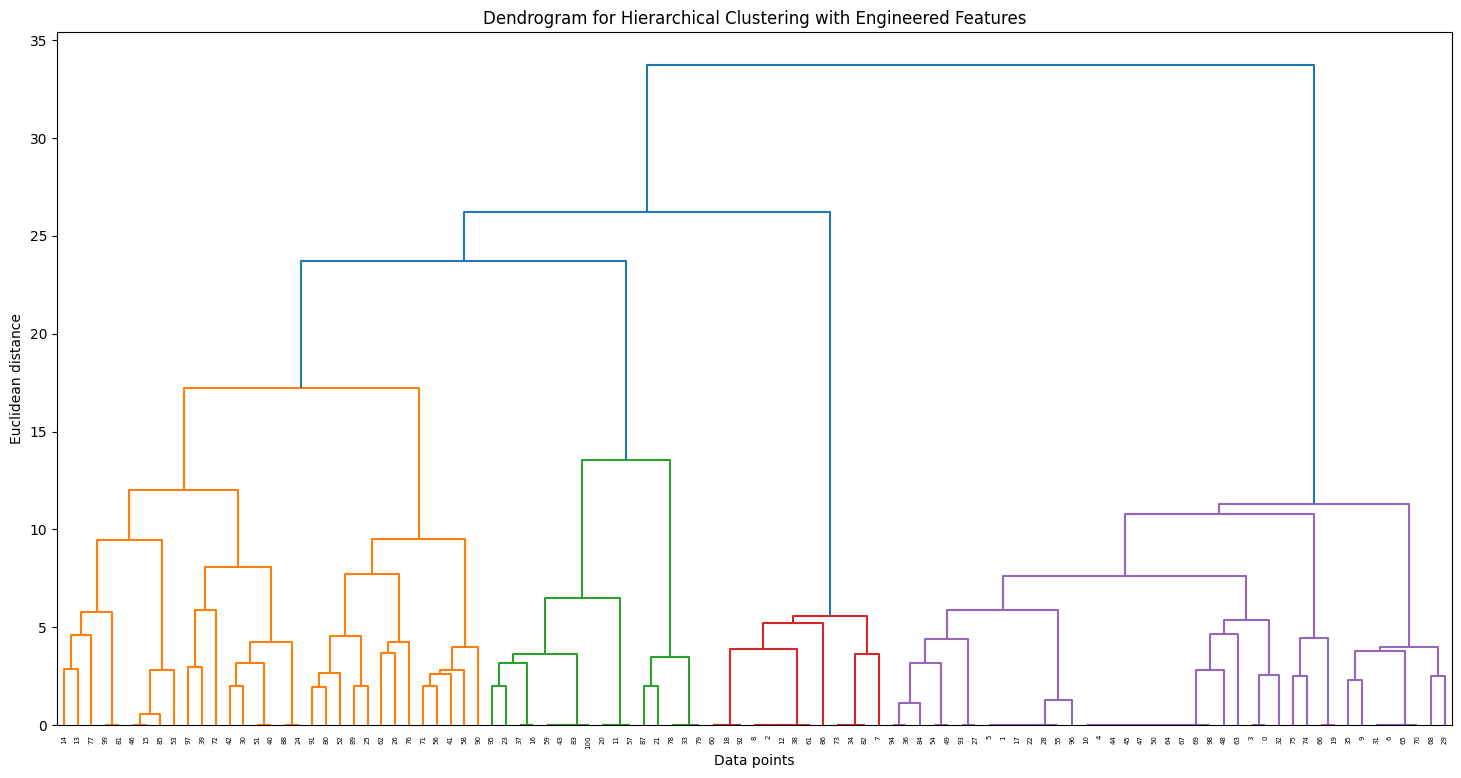

In [13]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(18, 9))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram for Hierarchical Clustering with Engineered Features')
plt.xlabel('Data points')
plt.ylabel('Euclidean distance')
plt.show()

In [17]:
from sklearn.cluster import AgglomerativeClustering

n_clusters = 3
hc_model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
clusters = hc_model.fit_predict(X_scaled)

X['cluster'] = clusters

display(X.head())

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,...,legs,tail,domestic,catsize,is_mammal,is_bird,is_fish_like,can_move_multiple_environments,has_many_legs,cluster
0,1,0,0,1,0,0,1,1,1,1,...,4,0,0,1,1,0,0,0,0,1
1,1,0,0,1,0,0,0,1,1,1,...,4,1,0,1,1,0,0,0,0,1
2,0,0,1,0,0,1,1,1,1,0,...,0,1,0,0,0,0,1,0,0,2
3,1,0,0,1,0,0,1,1,1,1,...,4,0,0,1,1,0,0,0,0,1
4,1,0,0,1,0,0,1,1,1,1,...,4,1,0,1,1,0,0,0,0,1


/tmp/ipykernel_997/1884666631.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster', data=X, palette='viridis')


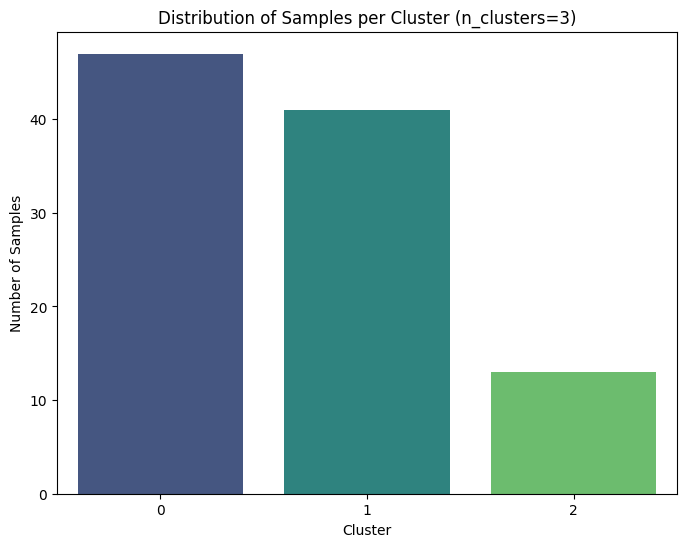

In [19]:
X['cluster'] = clusters

plt.figure(figsize=(8, 6))
sns.countplot(x='cluster', data=X, palette='viridis')
plt.title(f'Distribution of Samples per Cluster (n_clusters={n_clusters})')
plt.xlabel('Cluster')
plt.ylabel('Number of Samples')
plt.show()